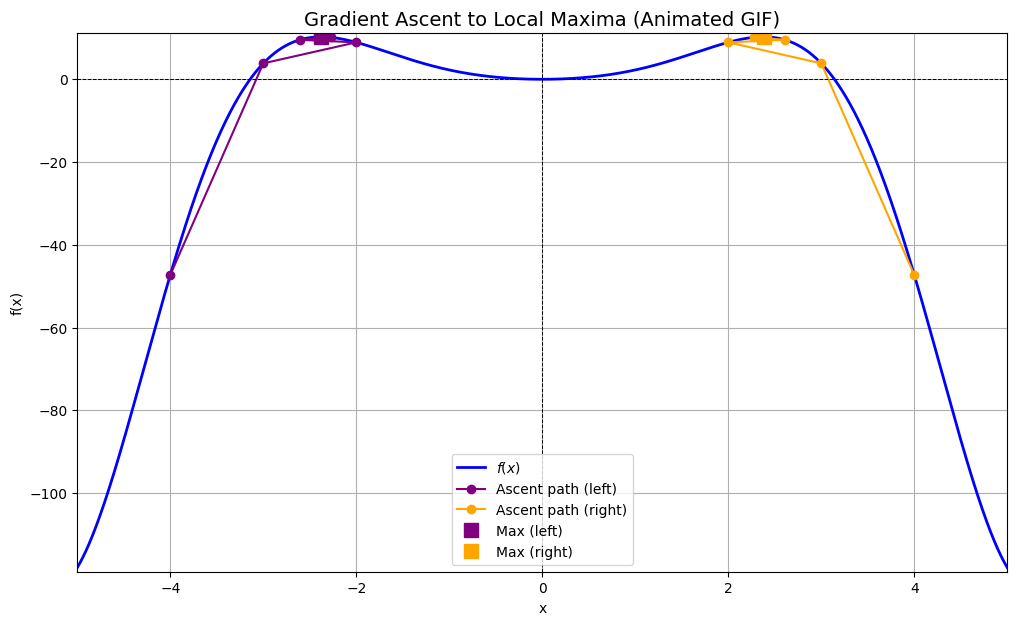

Final points after gradient ascent:
  From left:  x = -2.3788, f(x) = 10.2555
  From right: x = 2.3788, f(x) = 10.2555


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.animation as animation

# Define symbolic function
x = sp.Symbol('x')
f = x**3 * sp.sin(x) - sp.cos(2*x) + 1
f_prime = sp.diff(f, x)

# Lambdify numerical functions
f_lambd = sp.lambdify(x, f, 'numpy')
grad_lambd = sp.lambdify(x, f_prime, 'numpy')

# Gradient ascent with line search
def gradient_ascent_with_line_search(x0, max_iters=30, alpha_init=0.2, beta=0.5, step_cap=1.0):
    path = [x0]
    for i in range(max_iters):
        grad = grad_lambd(x0)
        if not np.isfinite(grad) or abs(grad) < 1e-6:
            break
        alpha = alpha_init
        while not np.isfinite(f_lambd(x0 + alpha * grad)) or f_lambd(x0 + alpha * grad) < f_lambd(x0):
            alpha *= beta
            if alpha < 1e-6:
                break
        step = alpha * grad
        if abs(step) > step_cap:
            step = np.sign(step) * step_cap
        x0 = x0 + step
        path.append(x0)
        if abs(x0) > 100:
            print("Terminating due to divergence.")
            break
    return path

# Run gradient ascent from left and right
x_start_left = -4
x_start_right = 4
path_left = gradient_ascent_with_line_search(x_start_left)
path_right = gradient_ascent_with_line_search(x_start_right)

# Compute function values for plot and paths
x_vals = np.linspace(-5, 5, 1000)
y_vals = f_lambd(x_vals)
valid_mask = np.isfinite(y_vals)
x_vals_valid = x_vals[valid_mask]
y_vals_valid = y_vals[valid_mask]

y_path_left = [f_lambd(xp) for xp in path_left]
y_path_right = [f_lambd(xp) for xp in path_right]

# Setup figure for animation
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x_vals_valid, y_vals_valid, label=r"$f(x)$", color='blue', linewidth=2)
point_left, = ax.plot([], [], 'o-', color='purple', label='Ascent path (left)', markersize=6)
point_right, = ax.plot([], [], 'o-', color='orange', label='Ascent path (right)', markersize=6)
final_max_left, = ax.plot([], [], 's', color='purple', markersize=10, label='Max (left)')
final_max_right, = ax.plot([], [], 's', color='orange', markersize=10, label='Max (right)')

ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=0.7)
ax.set_title("Gradient Ascent to Local Maxima (Animated GIF)", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.grid(True)
ax.legend()
ax.set_xlim(-5, 5)
ax.set_ylim(min(y_vals_valid)-1, max(y_vals_valid)+1)

# Animation update function with fix for scalar-to-sequence in set_data
def update(frame):
    if frame < len(path_left):
        x_left = path_left[:frame+1]
        y_left = y_path_left[:frame+1]
        point_left.set_data(x_left, y_left)
    if frame < len(path_right):
        x_right = path_right[:frame+1]
        y_right = y_path_right[:frame+1]
        point_right.set_data(x_right, y_right)
    if frame == len(path_left)-1:
        final_max_left.set_data([path_left[-1]], [y_path_left[-1]])  # wrap scalar in list
    if frame == len(path_right)-1:
        final_max_right.set_data([path_right[-1]], [y_path_right[-1]])  # wrap scalar in list
    return point_left, point_right, final_max_left, final_max_right

total_frames = max(len(path_left), len(path_right))

ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=600, blit=True)

# Save animation as GIF using pillow writer
ani.save("gradient_ascent_maxima.gif", writer='pillow', fps=1)

plt.show()

# Print final points
print("Final points after gradient ascent:")
print(f"  From left:  x = {path_left[-1]:.4f}, f(x) = {f_lambd(path_left[-1]):.4f}")
print(f"  From right: x = {path_right[-1]:.4f}, f(x) = {f_lambd(path_right[-1]):.4f}")


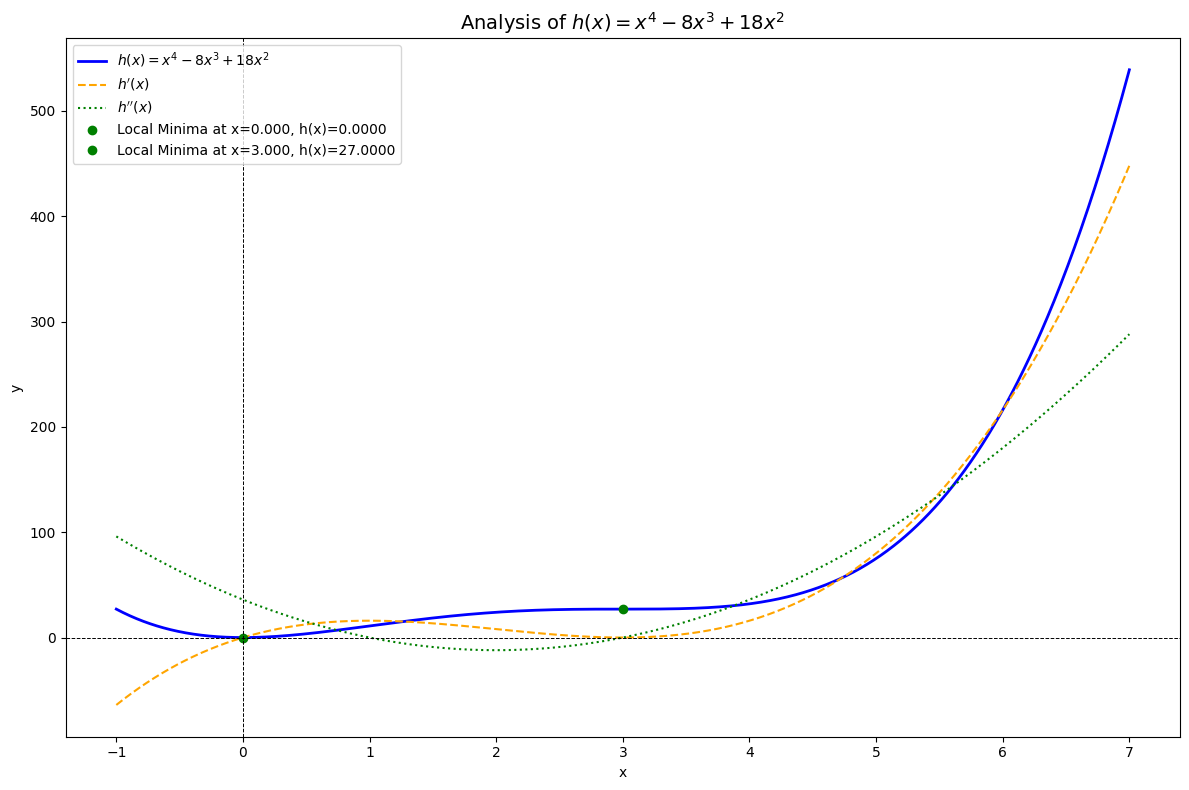

Critical Point Classification:

x = 0.0000, h(x) = 0.0000 → Local Minima
x = 3.0000, h(x) = 27.0000 → Local Minima


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Define the symbol and function
x = sp.Symbol('x')
h = x**4 - 8*x**3 + 18*x**2

# First and second derivatives
h_prime = sp.diff(h, x)
h_double_prime = sp.diff(h_prime, x)

# Solve h'(x) = 0 numerically using nsolve with various initial guesses
from sympy import nsolve

# Try multiple guesses across the domain to find multiple roots
initial_guesses = np.linspace(-1, 7, 30)  # range covering minima/maxima from earlier exploration
critical_points = []

for guess in initial_guesses:
    try:
        sol = float(nsolve(h_prime, x, guess))
        # Avoid near-duplicate solutions
        if all(abs(sol - cp) > 1e-4 for cp in critical_points):
            critical_points.append(sol)
    except:
        pass

# Convert symbolic expressions to numerical functions
h_lambd = sp.lambdify(x, h, 'numpy')
h_prime_lambd = sp.lambdify(x, h_prime, 'numpy')
h_double_prime_lambd = sp.lambdify(x, h_double_prime, 'numpy')

# Define x range for plotting
x_vals = np.linspace(-1, 7, 1200)
y_vals = h_lambd(x_vals)
y_prime_vals = h_prime_lambd(x_vals)
y_double_prime_vals = h_double_prime_lambd(x_vals)

# Classify critical points using second derivative test
classified_points = []
for cp in critical_points:
    f_val = h_lambd(cp)
    second = h_double_prime.evalf(subs={x: cp})
    if second > 0:
        classification = 'Local Minima'
    elif second < 0:
        classification = 'Local Maxima'
    else:
        classification = 'Inconclusive (f\'\'=0)'
    classified_points.append((cp, f_val, classification))

# ---------- PLOT FUNCTION AND DERIVATIVES ----------
plt.figure(figsize=(12, 8))

# Plot the function
plt.plot(x_vals, y_vals, label=r"$h(x) = x^4 - 8x^3 + 18x^2$", color='blue', linewidth=2)

# Plot first derivative
plt.plot(x_vals, y_prime_vals, label=r"$h'(x)$", color='orange', linestyle='--')

# Plot second derivative
plt.plot(x_vals, y_double_prime_vals, label=r"$h''(x)$", color='green', linestyle=':')

# Mark critical points with classification
for xp, yp, label in classified_points:
    color = 'green' if 'Min' in label else 'red' if 'Max' in label else 'gray'
    plt.plot(xp, yp, 'o', color=color, label=f'{label} at x={xp:.3f}, h(x)={yp:.4f}')

# Formatting
plt.axhline(0, color='black', linestyle='--', linewidth=0.7)
plt.axvline(0, color='black', linestyle='--', linewidth=0.7)
plt.title('Analysis of $h(x) = x^4 - 8x^3 + 18x^2$', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
# plt.grid(True)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# ---------- PRINT CLASSIFICATION ----------
print("Critical Point Classification:\n")
for xp, yp, label in sorted(classified_points):
    print(f"x = {xp:.4f}, h(x) = {yp:.4f} → {label}")


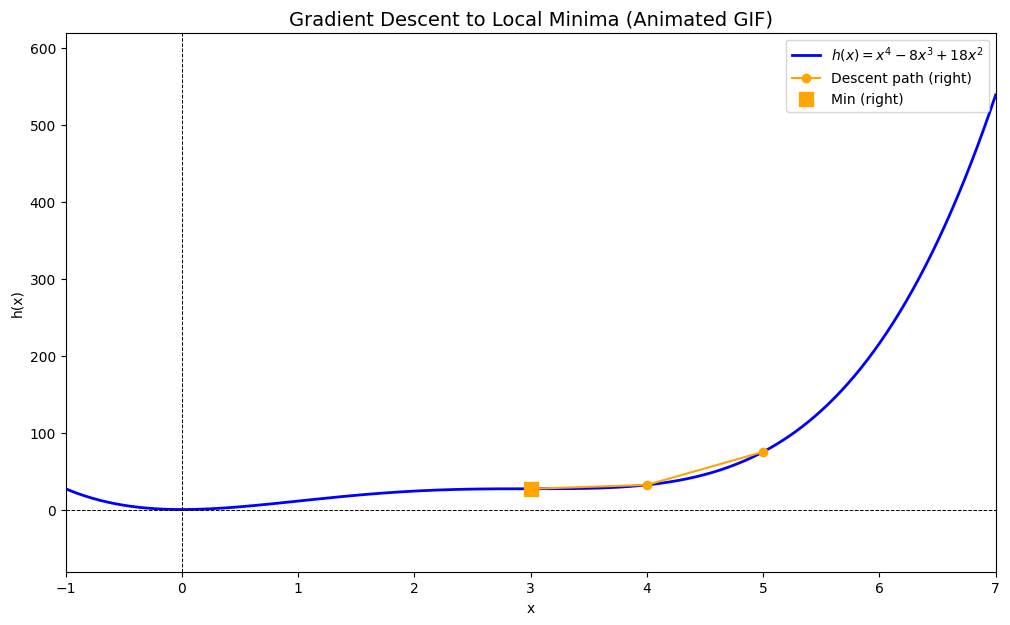

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.animation as animation

# Define symbolic function with multiple minima that moves from left start
x = sp.Symbol('x')
h = x**4 - 8*x**3 + 18*x**2
h_prime = sp.diff(h, x)

# Lambdify numerical functions
h_lambd = sp.lambdify(x, h, 'numpy')
grad_lambd = sp.lambdify(x, h_prime, 'numpy')

# Gradient descent with line search
def gradient_descent_with_line_search(x0, max_iters=30, alpha_init=0.2, beta=0.5, step_cap=1.0):
    path = [x0]
    for i in range(max_iters):
        grad = grad_lambd(x0)
        if not np.isfinite(grad) or abs(grad) < 1e-6:
            break
        alpha = alpha_init
        while not np.isfinite(h_lambd(x0 - alpha * grad)) or h_lambd(x0 - alpha * grad) > h_lambd(x0):
            alpha *= beta
            if alpha < 1e-6:
                break
        step = -alpha * grad
        if abs(step) > step_cap:
            step = np.sign(step) * step_cap
        x0 = x0 + step
        path.append(x0)
        if abs(x0) > 100:
            print("Terminating due to divergence.")
            break
    return path

# Starting points chosen so both paths move well
x_start_left = 0.5
x_start_right = 5.0
path_left = gradient_descent_with_line_search(x_start_left)
path_right = gradient_descent_with_line_search(x_start_right)

# Compute function values for plot and paths
x_vals = np.linspace(-1, 7, 1000)
y_vals = h_lambd(x_vals)
valid_mask = np.isfinite(y_vals)
x_vals_valid = x_vals[valid_mask]
y_vals_valid = y_vals[valid_mask]

y_path_left = [h_lambd(xp) for xp in path_left]
y_path_right = [h_lambd(xp) for xp in path_right]

# Setup figure for animation
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x_vals_valid, y_vals_valid, label=r"$h(x) = x^4 - 8x^3 + 18x^2$", color='blue', linewidth=2)
# point_left, = ax.plot([], [], 'o-', color='purple', label='Descent path (left)', markersize=6)
point_right, = ax.plot([], [], 'o-', color='orange', label='Descent path (right)', markersize=6)
# final_min_left, = ax.plot([], [], 's', color='purple', markersize=10, label='Min (left)')
final_min_right, = ax.plot([], [], 's', color='orange', markersize=10, label='Min (right)')

ax.axhline(0, color='black', linestyle='--', linewidth=0.7)
ax.axvline(0, color='black', linestyle='--', linewidth=0.7)
ax.set_title("Gradient Descent to Local Minima (Animated GIF)", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("h(x)")
# ax.grid(True)
ax.legend()
ax.set_xlim(-1, 7)

# Fix y-limits with padding for better visualization
y_min, y_max = np.min(y_vals_valid), np.max(y_vals_valid)
y_range = y_max - y_min
padding = 0.15 * y_range  # 15% padding
ax.set_ylim(y_min - padding, y_max + padding)

# Animation update function
def update(frame):
    # if frame < len(path_left):
    #     x_left = path_left[:frame+1]
    #     y_left = y_path_left[:frame+1]
    #     point_left.set_data(x_left, y_left)
    if frame < len(path_right):
        x_right = path_right[:frame+1]
        y_right = y_path_right[:frame+1]
        point_right.set_data(x_right, y_right)
    # if frame == len(path_left)-1:
    #     final_min_left.set_data([path_left[-1]], [y_path_left[-1]])
    if frame == len(path_right)-1:
        final_min_right.set_data([path_right[-1]], [y_path_right[-1]])
    # return point_left, point_right, final_min_left, final_min_right
    return point_right, final_min_right

# total_frames = max(len(path_left), len(path_right))
total_frames = len(path_right)

ani = animation.FuncAnimation(fig, update, frames=total_frames, interval=600, blit=True)

# Save animation as GIF using pillow writer
ani.save("gradient_descent_minima.gif", writer='pillow', fps=1)

plt.show()

# # Print final points
# print("Final points after gradient descent:")
# print(f"  From left:  x = {path_left[-1]:.4f}, h(x) = {h_lambd(path_left[-1]):.4f}")
# print(f"  From right: x = {path_right[-1]:.4f}, h(x) = {h_lambd(path_right[-1]):.4f}")


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.animation as animation

# ---------- Symbolic Function and Derivatives ----------
x = sp.Symbol('x')
h = x**4 - 8*x**3 + 18*x**2
h_prime = sp.diff(h, x)
h_double_prime = sp.diff(h_prime, x)

h_lambd = sp.lambdify(x, h, 'numpy')
h_prime_lambd = sp.lambdify(x, h_prime, 'numpy')
h_double_prime_lambd = sp.lambdify(x, h_double_prime, 'numpy')

# ---------- Critical Points ----------
from sympy import nsolve
initial_guesses = np.linspace(-1, 7, 30)
critical_points = []
for guess in initial_guesses:
    try:
        sol = float(nsolve(h_prime, x, guess))
        if all(abs(sol - cp) > 1e-4 for cp in critical_points):
            critical_points.append(sol)
    except:
        pass

classified_points = []
for cp in critical_points:
    f_val = h_lambd(cp)
    second = h_double_prime.evalf(subs={x: cp})
    if second > 0:
        classification = 'Local Minima'
    elif second < 0:
        classification = 'Local Maxima'
    else:
        classification = 'Inconclusive (f\'\'=0)'
    classified_points.append((cp, f_val, classification))

# ---------- Gradient Descent ----------
def gradient_descent_path(x0, max_iters=30, alpha_init=0.2, beta=0.5, step_cap=1.0):
    path = [x0]
    for _ in range(max_iters):
        grad = h_prime_lambd(x0)
        if not np.isfinite(grad) or abs(grad) < 1e-6:
            break
        alpha = alpha_init
        while not np.isfinite(h_lambd(x0 - alpha * grad)) or h_lambd(x0 - alpha * grad) > h_lambd(x0):
            alpha *= beta
            if alpha < 1e-6:
                break
        step = -alpha * grad
        step = np.clip(step, -step_cap, step_cap)
        x0 = x0 + step
        path.append(x0)
        if abs(x0) > 100:
            break
    return path

# Descent paths
path_left = gradient_descent_path(0.5)
path_right = gradient_descent_path(5.0)
y_path_left = [h_lambd(xi) for xi in path_left]
y_path_right = [h_lambd(xi) for xi in path_right]

# ---------- Animate Left Path in Segments ----------
def animate_left_segment(start_idx, end_idx, filename, show_final_marker=False):
    segment_x = path_left[start_idx:end_idx + 1]
    segment_y = [h_lambd(xi) for xi in segment_x]

    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Background function curve: zoomed region
    x_plot = np.linspace(min(segment_x)-0.1, max(segment_x)+0.1, 500)
    y_plot = h_lambd(x_plot)
    ax.plot(x_plot, y_plot, color='blue', label='h(x)')
    
    descent_line, = ax.plot([], [], 'o-', color='purple', label='Left Descent')
    final_marker = ax.plot([], [], 's', color='purple', markersize=8, label='Final Point')[0] if show_final_marker else None

    # Zoom limits
    x_min, x_max = min(segment_x), max(segment_x)
    y_min, y_max = min(segment_y), max(segment_y)
    x_pad = 0.2 * (x_max - x_min + 1e-6)
    y_pad = 0.2 * (y_max - y_min + 1e-6)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)

    ax.set_title(f"Gradient Descent (Left) Steps {start_idx}-{end_idx}", fontsize=12)
    ax.set_xlabel("x")
    ax.set_ylabel("h(x)")
    ax.legend()
    ax.grid(True)

    def update(i):
        descent_line.set_data(segment_x[:i+1], segment_y[:i+1])
        if show_final_marker and i == len(segment_x) - 1:
            final_marker.set_data([segment_x[-1]], [segment_y[-1]])
        return [descent_line] + ([final_marker] if show_final_marker else [])

    ani = animation.FuncAnimation(fig, update, frames=len(segment_x), interval=600, blit=True)
    ani.save(filename, writer='pillow', fps=1)
    plt.close(fig)

# Split into 3 zoomed animations
animate_left_segment(0, min(9, len(path_left)-1), "descent_left_part1.gif", show_final_marker=False)
animate_left_segment(10, min(19, len(path_left)-1), "descent_left_part2.gif", show_final_marker=False)
animate_left_segment(20, len(path_left)-1, "descent_left_part3.gif", show_final_marker=True)

# ---------- Animate Right (Full View) ----------
x_vals = np.linspace(-1, 7, 1200)
y_vals = h_lambd(x_vals)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_vals, y_vals, label="h(x)", color='blue')
point_right, = ax.plot([], [], 'o-', color='orange', label='Descent Path (Right)')
final_right, = ax.plot([], [], 's', color='orange', markersize=8, label='Min (Right)')

ax.set_xlim(-1, 7)
y_min, y_max = np.min(y_vals), np.max(y_vals)
padding = 0.15 * (y_max - y_min)
ax.set_ylim(y_min - padding, y_max + padding)
ax.set_title("Gradient Descent from Right", fontsize=13)
ax.set_xlabel("x")
ax.set_ylabel("h(x)")
ax.grid(True)
ax.legend()

def update_right(i):
    point_right.set_data(path_right[:i+1], y_path_right[:i+1])
    if i == len(path_right) - 1:
        final_right.set_data([path_right[-1]], [y_path_right[-1]])
    return point_right, final_right

ani_right = animation.FuncAnimation(fig, update_right, frames=len(path_right), interval=600, blit=True)
ani_right.save("descent_right.gif", writer='pillow', fps=1)
plt.close(fig)

# ---------- Print Classification ----------
print("Critical Point Classification:\n")
for xp, yp, label in sorted(classified_points):
    print(f"x = {xp:.4f}, h(x) = {yp:.4f} → {label}")


Critical Point Classification:

x = 0.0000, h(x) = 0.0000 → Local Minima
x = 3.0000, h(x) = 27.0000 → Local Minima


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import matplotlib.animation as animation

# -----------------------------
# Define the symbolic function
# -----------------------------
x = sp.Symbol('x')
h_expr = x**4 - 8*x**3 + 18*x**2
h = sp.lambdify(x, h_expr, 'numpy')
h_prime = sp.lambdify(x, sp.diff(h_expr, x), 'numpy')

# -----------------------------
# Gradient Descent from Left
# -----------------------------
def gradient_descent_path(x0, max_iters=30, alpha_init=0.2, beta=0.5, step_cap=1.0):
    path = [x0]
    for _ in range(max_iters):
        grad = h_prime(x0)
        if not np.isfinite(grad) or abs(grad) < 1e-6:
            break
        alpha = alpha_init
        while not np.isfinite(h(x0 - alpha * grad)) or h(x0 - alpha * grad) > h(x0):
            alpha *= beta
            if alpha < 1e-6:
                break
        step = -alpha * grad
        step = np.clip(step, -step_cap, step_cap)
        x0 = x0 + step
        path.append(x0)
        if abs(x0) > 100:
            break
    return path

# Generate path and values
path_left = gradient_descent_path(0.5)
y_path_left = [h(xi) for xi in path_left]

# -----------------------------
# Compute Adaptive Zoom Windows
# -----------------------------
def compute_adaptive_limits(xs, ys, min_pad=0.01):
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_pad = max(min_pad, 0.1 * abs(x_max - x_min))
    y_pad = max(min_pad, 0.1 * abs(y_max - y_min))
    return (x_min - x_pad, x_max + x_pad), (y_min - y_pad, y_max + y_pad)

segments = [(0, 9), (10, 19), (20, len(path_left)-1)]
zoom_windows = []

for start, end in segments:
    xs = path_left[start:end+1]
    ys = y_path_left[start:end+1]
    xlim, ylim = compute_adaptive_limits(xs, ys)
    zoom_windows.append((xlim, ylim))

# -----------------------------
# Create Animation with Smooth Zoom
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Function curve (global view for background)
h_vals_x = np.linspace(-1, 1, 1000)
h_vals_y = h(h_vals_x)
curve_line, = ax.plot(h_vals_x, h_vals_y, label="h(x)", color='blue')

# Descent path and marker
descent_line, = ax.plot([], [], 'o-', color='purple', label='Descent Path')
final_marker, = ax.plot([], [], 's', color='purple', markersize=8, label='Final Point')

ax.set_xlabel("x")
ax.set_ylabel("h(x)")
ax.set_title("Gradient Descent from Left with Smooth Zoom")
ax.grid(True)
ax.legend()

# Interpolate axis limits based on segment
def interpolate_limits(frame_idx):
    if frame_idx < 10:
        frac = frame_idx / 10
        xlim = np.array(zoom_windows[0][0]) * (1 - frac) + np.array(zoom_windows[1][0]) * frac
        ylim = np.array(zoom_windows[0][1]) * (1 - frac) + np.array(zoom_windows[1][1]) * frac
    elif frame_idx < 20:
        frac = (frame_idx - 10) / 10
        xlim = np.array(zoom_windows[1][0]) * (1 - frac) + np.array(zoom_windows[2][0]) * frac
        ylim = np.array(zoom_windows[1][1]) * (1 - frac) + np.array(zoom_windows[2][1]) * frac
    else:
        xlim = zoom_windows[2][0]
        ylim = zoom_windows[2][1]
    return xlim, ylim

# Update function for animation
def update(frame):
    x_path = path_left[:frame+1]
    y_path = y_path_left[:frame+1]
    descent_line.set_data(x_path, y_path)

    if frame == len(path_left) - 1:
        final_marker.set_data([x_path[-1]], [y_path[-1]])
    else:
        final_marker.set_data([], [])

    xlim, ylim = interpolate_limits(frame)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)

    return descent_line, final_marker, curve_line

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(path_left), interval=600, blit=True)

# Save as GIF
ani.save("combined_smooth_zoom_left.gif", writer='pillow', fps=1)
plt.close(fig)

print("Animation saved as 'combined_smooth_zoom_left.gif'")
